Training a basic neural network 

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

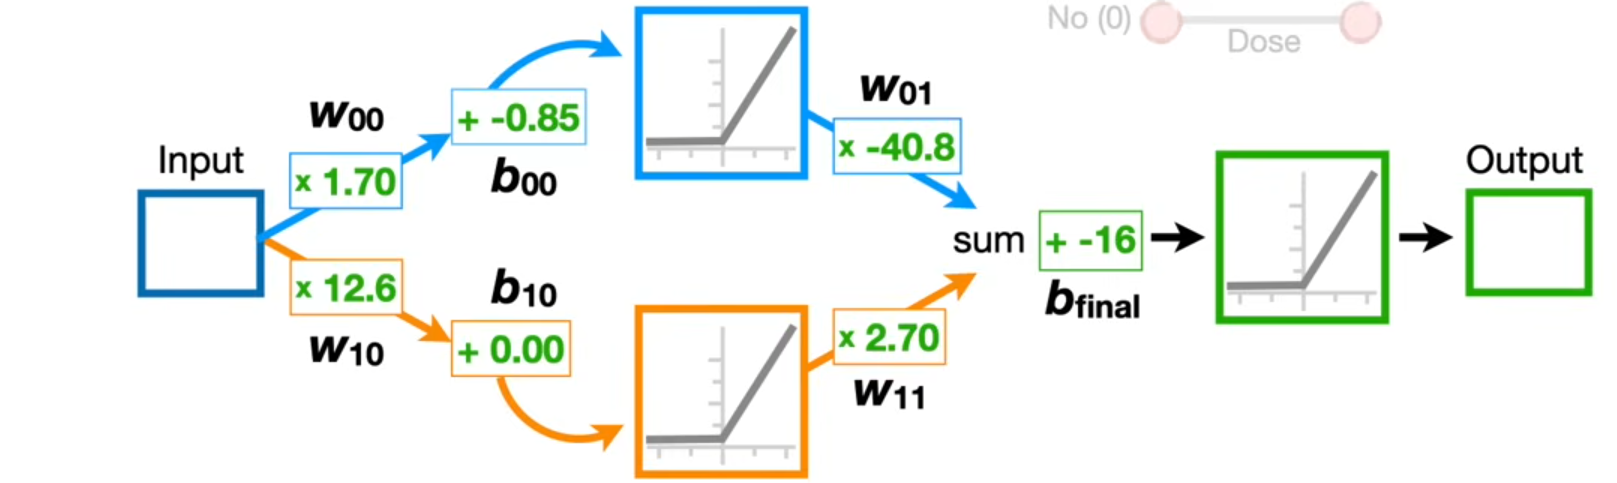

The network we are trying to make

In [3]:
class BasicNN_train(nn.Module):           # initializing a neural net class inherited from the parent class Module in the torch.nn module
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)       # inheriting the properties of the parent class

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad= False)    # putting the value of the parameter as tensor
        # requires_grad property of the Parameter class allows to optimize or not optimize the parameter 

        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad= False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad= False)
        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad= False)
        self.b10 = nn.Parameter(torch.tensor(0.00), requires_grad= False)
        self.w11 = nn.Parameter(torch.tensor(2.70), requires_grad= False)

        self.final_bias = nn.Parameter(torch.tensor(0.0), requires_grad= True)     # this parameter should be optimized

    # creating the forward pass 

    def forwarding(self, input):

        #creating top connections
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        #creating bottom connections
        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        #final combination of top and bottom connection
        input_to_final_relu = scaled_bottom_relu_output + scaled_top_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output
    


In [4]:
input_values = torch.linspace(start = 0, end = 1, steps = 11)  # creating a tensor with a sequence of 11 values between and including 0 and 1

In [5]:
input_values

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [6]:
model = BasicNN_train()

output_values = model.forwarding(input_values)


Text(0, 0.5, 'RELU output')

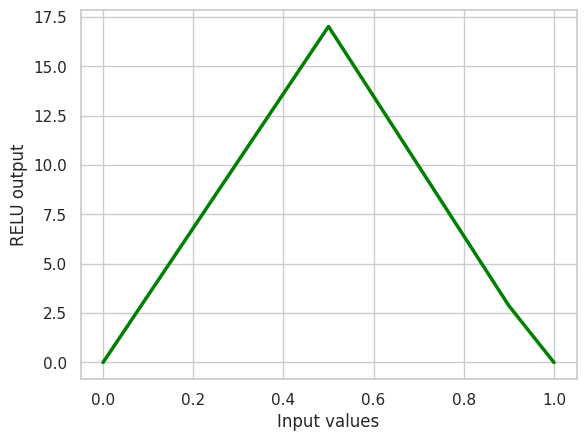

In [7]:
sns.set(style= 'whitegrid')
# since seaborn doesnt know what to do with the gradient, we strip it off with detach
sns.lineplot(x = input_values, y = output_values.detach(), color = "green", linewidth = 2.5) 
plt.xlabel("Input values")
plt.ylabel("RELU output")

## Backpropagation

Optimizing the final bias parameter

In [8]:
optimizer = SGD(model.parameters(), lr = 0.1)       # defining optimizer with learning rate of 0.1

In [9]:
# each time our optimization code sees all of the data is called an epoch

inputs = torch.tensor([0., 0.5, 1.])
lables = torch.tensor([0., 1., 0.])

for epoch in range(100):
    
    total_loss = 0

    for iterations in range(len(inputs)):    # nested loop that runs each data points through model and calculates total loss
        
        input_i = inputs[iterations]
        label_i = lables[iterations]

        output_i = model.forwarding(input_i)

        loss = (output_i - label_i)**2      # R square loss function

        loss.backward()     # computes the gradient of the loss function with respect to the parameter/s we want to optimize
        # loss.backwards() remembers the derivative for the previous point and adds the new one to the previous one 

        total_loss += float(loss)

    if total_loss < 0.0001:
        print("Num steps :" + str(epoch))
        break

    optimizer.step()        # take a small step towards the better value of the parameter 
    # this method has the access to the derivates stored in the model and can use them to step in the correct direction
    optimizer.zero_grad()   # zero out the derivates for one epoch otherwise it will store the derivates of the last epoch

    print("step" + str(epoch) + "Final Bias : " + str(model.final_bias.data) + "\n")

print(f"Most optimal value for the Bias : {model.final_bias.data}")



step0Final Bias : tensor(-3.2020)

step1Final Bias : tensor(-5.7636)

step2Final Bias : tensor(-7.8129)

step3Final Bias : tensor(-9.4523)

step4Final Bias : tensor(-10.7638)

step5Final Bias : tensor(-11.8131)

step6Final Bias : tensor(-12.6525)

step7Final Bias : tensor(-13.3240)

step8Final Bias : tensor(-13.8612)

step9Final Bias : tensor(-14.2909)

step10Final Bias : tensor(-14.6348)

step11Final Bias : tensor(-14.9098)

step12Final Bias : tensor(-15.1298)

step13Final Bias : tensor(-15.3059)

step14Final Bias : tensor(-15.4467)

step15Final Bias : tensor(-15.5594)

step16Final Bias : tensor(-15.6495)

step17Final Bias : tensor(-15.7216)

step18Final Bias : tensor(-15.7793)

step19Final Bias : tensor(-15.8254)

step20Final Bias : tensor(-15.8623)

step21Final Bias : tensor(-15.8919)

step22Final Bias : tensor(-15.9155)

step23Final Bias : tensor(-15.9344)

step24Final Bias : tensor(-15.9495)

step25Final Bias : tensor(-15.9616)

step26Final Bias : tensor(-15.9713)

step27Final Bia

Text(0.5, 0, 'Input values')

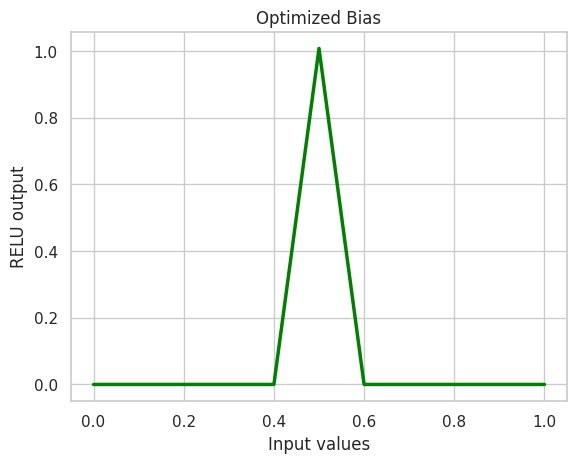

In [10]:
output_values = model.forwarding(input_values)

sns.set_style("whitegrid")

sns.lineplot(x = input_values, y = output_values.detach(), color = "green", linewidth = 2.5)

plt.title("Optimized Bias")
plt.ylabel("RELU output")
plt.xlabel("Input values")



In [14]:
import lightning as L 
from torch.utils.data import dataloader, TensorDataset      # makes it easier to work with larger datasets


ImportError: cannot import name 'VGG16_Weights' from 'torchvision.models' (/home/arbiter/projects/Recalibration-deep-learning/.env/lib/python3.13/site-packages/torchvision/models/__init__.py)

In [15]:
import lightning

ImportError: cannot import name 'VGG16_Weights' from 'torchvision.models' (/home/arbiter/projects/Recalibration-deep-learning/.env/lib/python3.13/site-packages/torchvision/models/__init__.py)